In [50]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from scipy.spatial import cKDTree
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import classification_report, precision_recall_curve, f1_score, precision_score, recall_score, average_precision_score, r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import minmax_scale
from sklearn.linear_model import Ridge
from sklearn.dummy import DummyRegressor
from catboost import CatBoostClassifier
pd.set_option('future.no_silent_downcasting', True)

In [51]:
df = pd.read_csv('Heracleum mantegazzianum.csv', engine='pyarrow')
df_weather = pd.read_csv('knmi_weather_cache.csv', engine='pyarrow')
df_habitats = pd.read_csv('habitats_cbs_2022.csv', engine='pyarrow')

#df.sample(10)
#df_weather.sample(10)
#df_habitats.sample(10)

In [52]:
df.info(verbose=True)
df.describe()

df_weather.info(verbose=True)
df_weather.describe()

df_habitats.info(verbose=True)
df_habitats.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12558786 entries, 0 to 12558785
Data columns (total 6 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   decimalLatitude            float64
 1   decimalLongitude           float64
 2   eventDate                  object 
 3   total_observations         float64
 4   speciesgroup_observations  int64  
 5   Heracleum mantegazzianum   object 
dtypes: float64(3), int64(1), object(2)
memory usage: 574.9+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5844 entries, 0 to 5843
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              5844 non-null   object 
 1   mean_temp_c       5844 non-null   float64
 2   max_temp_c        5844 non-null   float64
 3   min_temp_c        5844 non-null   float64
 4   precipitation_mm  5844 non-null   float64
dtypes: float64(4), object(1)
memory usage: 228.4+ KB
<class 'panda

,decimalLongitude,decimalLatitude,agricultural,built,coast,forest,other,sand/heather,water,wetland
count,2179.000000,2179.000000,2179.000000,2179.000000,2179.000000,2179.000000,2179.000000,2179.000000,2179.000000,2179.000000
mean,5.510624,52.242336,9.571166,2.600712,1.510309,1.816148,1.716892,0.405040,1.461374,0.414471
std,0.890036,0.664786,5.303015,3.053375,4.443380,3.040838,2.366745,2.245601,3.402881,2.089655
min,3.350000,50.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.850000,51.700000,5.394250,0.780050,0.000000,0.153250,0.735300,0.000000,0.102800,0.000000
50%,5.650000,52.200000,10.623900,1.584300,0.000000,0.735100,1.213500,0.000000,0.318300,0.019300
75%,6.150000,52.800000,13.883000,3.391350,0.000000,2.123850,2.042500,0.027000,1.096200,0.157850
max,7.200000,53.500000,29.522800,29.835000,28.982000,28.075200,29.906000,29.408500,29.863600,28.847500


In [53]:
#df[df.duplicated()] true

From the initial data description, it is visible that not all columns have the correct data types. The *eventDate* column should be formatted in **datetime** instead of in **string**, the *total_observations* column is formatted as **float**, and while that's usable, it should be of the **integer** type instead, and finally the *Heracleum mantegazzianum* column is in **string**, while that should be an **integer** column as well.

From the above duplicate check, it is also visible that there are **no** duplicates. (Ruben)

In [54]:
for col in df.columns:
    uniques = df[col].unique()[:10].tolist()
    print(f"{col}: {uniques}...")
print(df.head(5).to_string())

decimalLatitude: [50.75, 50.8, 50.85, 50.9, 50.95, 51.0, 51.05, 51.1, 51.15, 51.2]...
decimalLongitude: [5.65, 5.7, 5.75, 5.8, 5.85, 5.9, 5.95, 6.0, 5.6, 6.05]...
eventDate: [datetime.date(2010, 1, 1), datetime.date(2010, 1, 2), datetime.date(2010, 1, 3), datetime.date(2010, 1, 4), datetime.date(2010, 1, 5), datetime.date(2010, 1, 6), datetime.date(2010, 1, 7), datetime.date(2010, 1, 8), datetime.date(2010, 1, 9), datetime.date(2010, 1, 10)]...
total_observations: [0.0, 26.0, 3.0, 1.0, 18.0, 11.0, 6.0, 7.0, 5.0, 12.0]...
speciesgroup_observations: [0, 1, 15, 11, 13, 3, 42, 46, 9, 7]...
Heracleum mantegazzianum: ['0', '2', '1', '3', '5', '4', '6', '7', '8', '10']...
   decimalLatitude  decimalLongitude   eventDate  total_observations  speciesgroup_observations Heracleum mantegazzianum
0            50.75              5.65  2010-01-01                 0.0                          0                        0
1            50.75              5.65  2010-01-02                26.0                

TLDR;
some **NAN** values in total_observations
Heracleum mantegazzianum array has some *unknown* and *-1 negative values* (Mika)

In [55]:
df['total_observations'] = pd.to_numeric(df['total_observations'], errors='coerce')
df['total_observations'] = df['total_observations'].fillna(0).astype(np.int32)
df['speciesgroup_observations'] = df['speciesgroup_observations'].astype(np.int32)
df['decimalLatitude'] = df['decimalLatitude'].astype(np.float32)
df['decimalLongitude'] = df['decimalLongitude'].astype(np.float32)
#print(df['total_observations'].dtype, len(df['total_observations']))
df_weather['date'] = pd.to_datetime(df_weather['date'])
df_weather['mean_temp_c'] = df_weather['mean_temp_c'].astype(np.float32)
df_weather['max_temp_c'] = df_weather['max_temp_c'].astype(np.float32)
df_weather['min_temp_c'] = df_weather['min_temp_c'].astype(np.float32)
df_weather['precipitation_mm'] = df_weather['precipitation_mm'].astype(np.float32)
#df_weather['']

I observed that the total_observations column was with float values and NaNs. To mitigate this, I converted all NaNs to 0 and all values from float to int. (Marcell)

In [56]:
cat_series = df['Heracleum mantegazzianum'].astype('category')
unique_cats = pd.to_numeric(cat_series.cat.categories, errors='coerce').to_numpy()
clean_cats = np.where(np.isnan(unique_cats) | (unique_cats < 0), 0, unique_cats).astype(np.int16)
df['Heracleum mantegazzianum'] = clean_cats[cat_series.cat.codes]

The Heracleum mantegazzianum column was originally in a string format. All unknown / NaN values were converted to 0 and all others including the new 0s were converted to integers. Furthermore, all values below 0 were raised to 0 as there was at least 1 instance where the row value was below 0 (-1). (Marcell)

In [57]:
df['eventDate'] = pd.to_datetime(df['eventDate'], errors='coerce')
#df['eventDate'].sample(10)

In [58]:
df_merged = df.merge(df_weather, left_on='eventDate', right_on='date', how='left')
df_merged = df_merged.drop(columns='date')

# df_merged.info(verbose=True)

The *weather* and *observation* datasets were merged here. (Ruben)

The *eventDate* column was with *string* values instead of *datetime* values. To correct this, I changed the eventDate column to be of the ***datetime data type***. (Ruben)

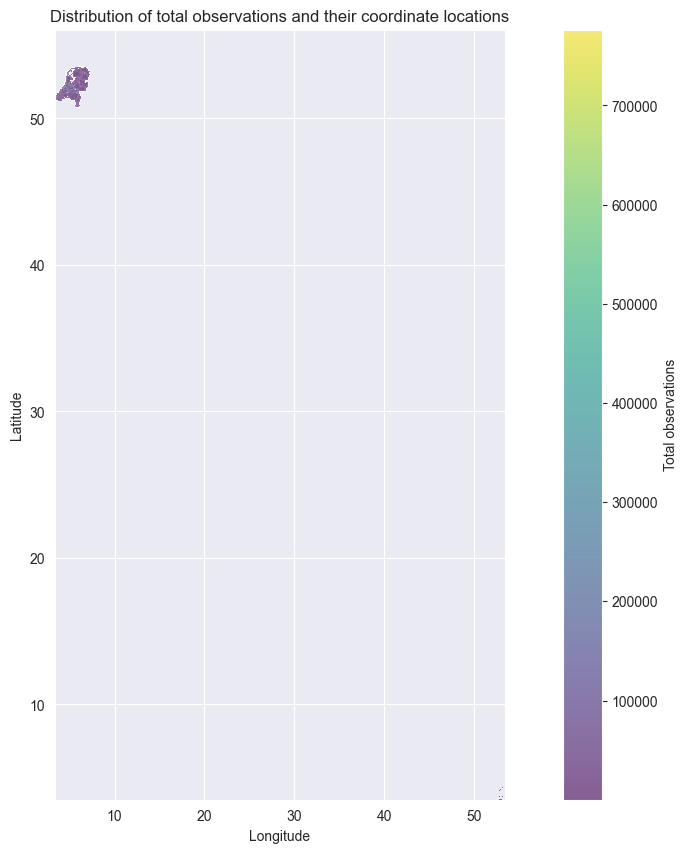

In [59]:
nl_layer = gpd.read_file("gadm41_NLD.gpkg", layer="ADM_ADM_1")
def show_distribution_map(df_map, nl):
    fig, ax = plt.subplots(figsize=(15, 10))
    nl.plot(ax=ax, color='lightgray', edgecolor='white')

    bin_w = 0.05
    x_bins = np.arange(df_map['decimalLongitude'].min(), df_map['decimalLongitude'].max() + bin_w, bin_w)
    y_bins = np.arange(df_map['decimalLatitude'].min(), df_map['decimalLatitude'].max() + bin_w, bin_w)

    heatmap, xedges, yedges = np.histogram2d(
        df_map['decimalLongitude'],
        df_map['decimalLatitude'],
        bins=[x_bins, y_bins],
        weights=df_map['total_observations']
    )

    heatmap = np.where(heatmap == 0, np.nan, heatmap)
    mesh = ax.pcolormesh(
        xedges,
        yedges,
        heatmap.T,
        alpha=0.6,
        cmap='viridis'
    )
    fig.colorbar(mesh, ax=ax, label='Total observations')
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title("Distribution of total observations and their coordinate locations")
    plt.show()

show_distribution_map(df_merged, nl_layer)

I took the latitude and longitude coordinates from the observations, and applied them in a *distplot* to show ***distribution of observations*** by using the *total_observations* column as a weight. This is done to learn where most observations are made. This means we have also learnt that some observations appear to have been made in ***Somalia***. Either that or the coordinates of those observations have been **inverted**. This is something to fix before we move forward.

We can either choose to *invert* these values and fix them, or choose to *remove them. Ideally, we shall do the former.

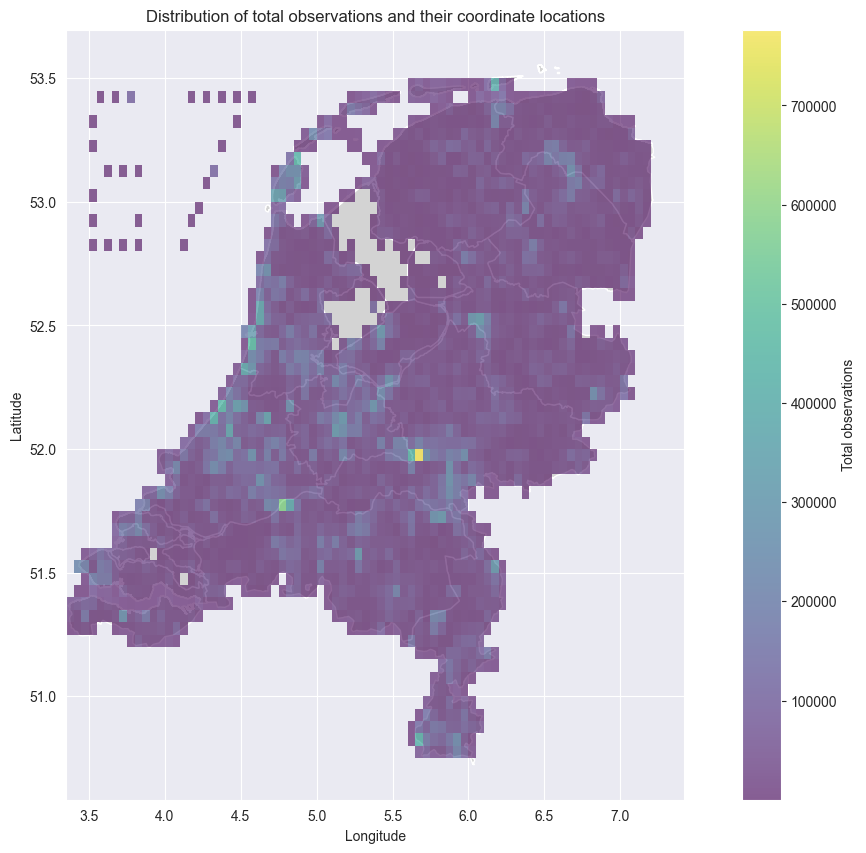

In [60]:
df_nlmap = df_merged[['decimalLatitude','decimalLongitude', 'total_observations']].copy()
mask = ((df_nlmap['decimalLatitude'] < 10) & (df_nlmap['decimalLongitude'] > 40))
df_nlmap.loc[mask, ['decimalLatitude', 'decimalLongitude']] = df_nlmap.loc[mask, ['decimalLongitude', 'decimalLatitude']].values

show_distribution_map(df_nlmap, nl_layer)

I *inverted* the coordinates so they can show up properly on the map. However, now we can see that someone was trying to be funny and added a random 67 to the map. We will need to remove this.

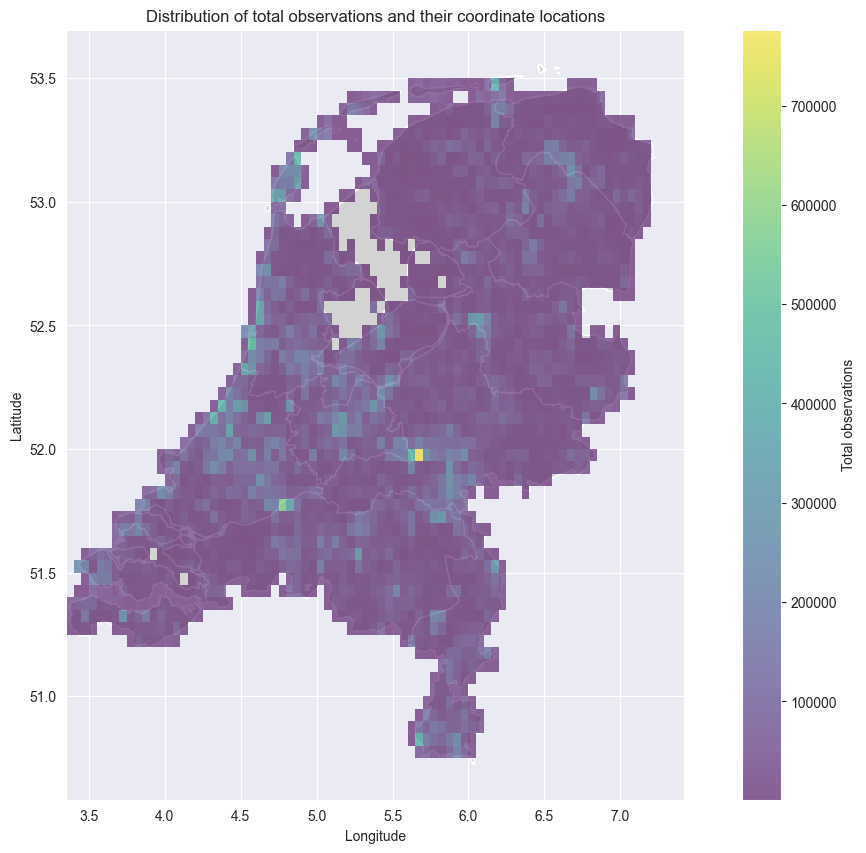

In [61]:
df_merged = df_merged[
    (df_merged['decimalLatitude'].between(50.7, 53.6)) &
    (df_merged['decimalLongitude'].between(3.3, 7.2))]

show_distribution_map(df_merged, nl_layer)

Here the 67 was *removed* from the map.

<Axes: >

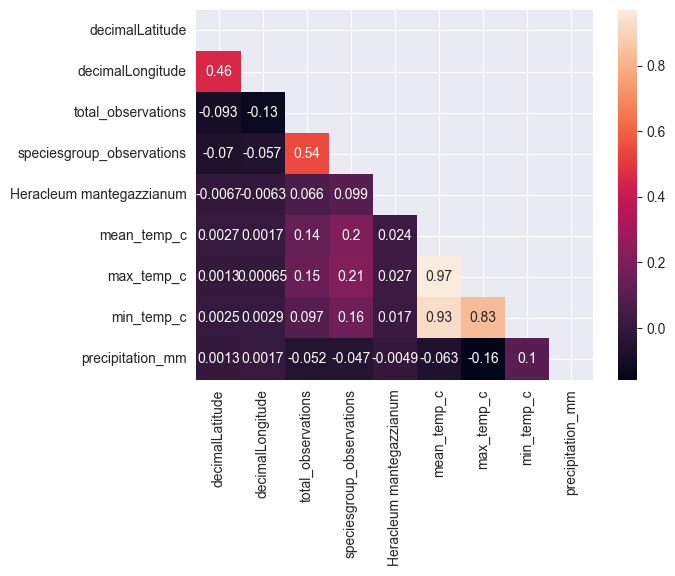

In [62]:
df_corr_sample = df_merged.sample(100000, random_state=42)
df_corr = df_corr_sample.corr(method='spearman', numeric_only=True)
mask = np.triu(np.ones_like(df_corr, dtype=bool))
sns.heatmap(df_corr, annot=True, mask=mask)

Upon creating a quick correlation matrix we can conclude there's some correlation between total_observations and speciesgroup_observations as well as minor correlation between speciesgroup_observation and our target value. There is also high correlation between latitude and longitude. This makes perfect sense.

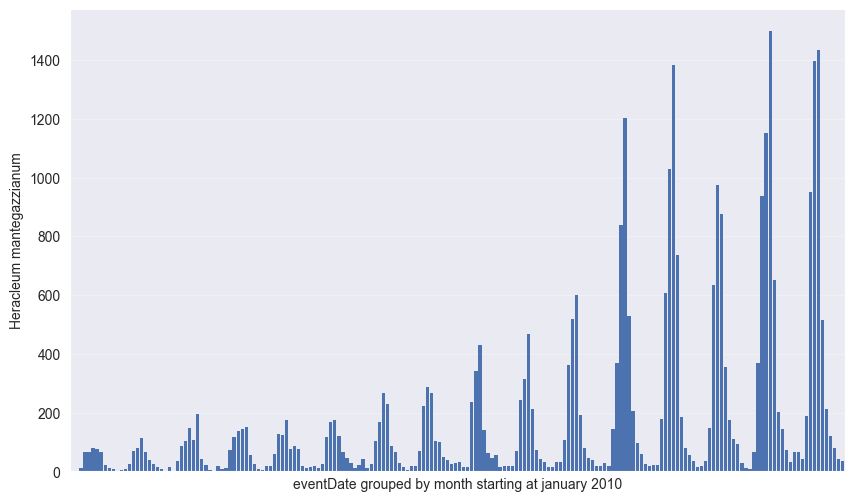

In [63]:
df_months = df_merged.groupby(df_merged['eventDate'].dt.to_period('M'))['Heracleum mantegazzianum'].sum()
fig, ax = plt.subplots(figsize=(10, 6))
df_months.plot(kind='bar', ax=ax, width=0.8, color='#4c72b0', edgecolor='none')

ax.set_xticks([])
ax.set_xlabel("eventDate grouped by month starting at january 2010")
ax.set_ylabel("Heracleum mantegazzianum")
ax.grid(axis='y', linestyle='-', alpha=0.3)
ax.set_axisbelow(True)
plt.show()

<Axes: xlabel='eventDate', ylabel='Heracleum mantegazzianum'>

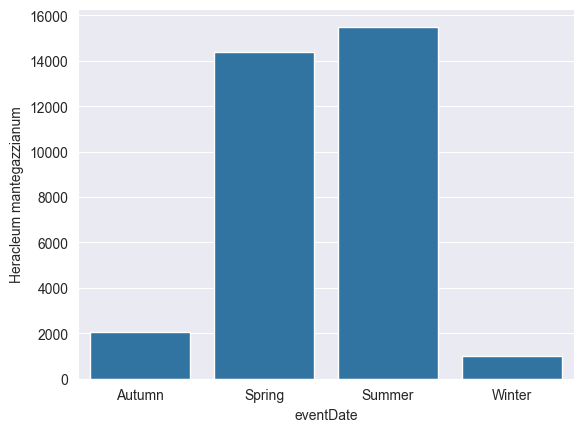

In [64]:
win: str = "Winter"
spr: str = "Spring"
smr: str = "Summer"
aut: str = "Autumn"

season_map = {
    12: win, 1: win, 2: win,
    3: spr, 4: spr, 5: spr,
    6: smr, 7: smr, 8: smr,
    9: aut, 10: aut, 11: aut }

df_months = df_merged[['eventDate', 'Heracleum mantegazzianum']].copy()
df_months['eventDate'] = df_months['eventDate'].dt.month.map(season_map)
df_months = df_months.groupby('eventDate').sum(numeric_only=True)

sns.barplot(data=df_months, x='eventDate', y='Heracleum mantegazzianum')

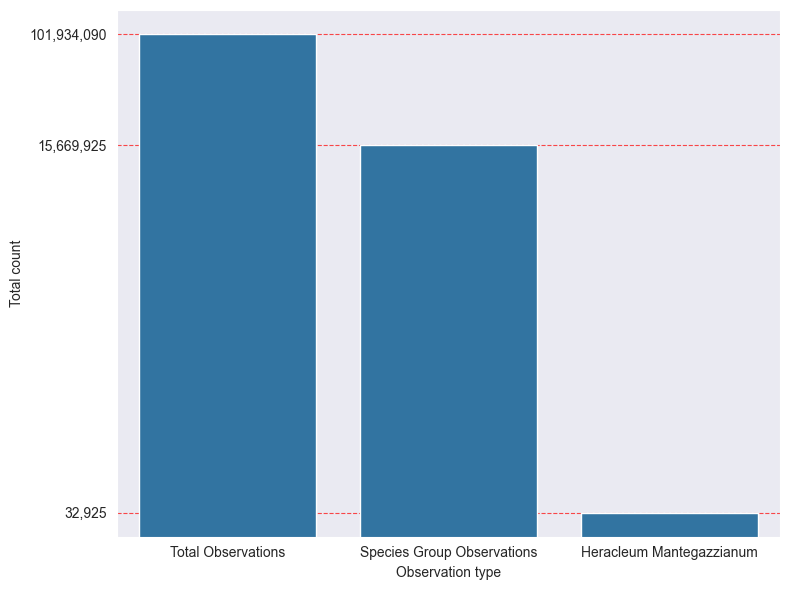

In [65]:
bias_df = df_merged[['total_observations', 'speciesgroup_observations', 'Heracleum mantegazzianum']]
bias_df = bias_df.sum().reset_index()
bias_df.columns = ['Observation type', 'Total count']

label_map = {
    'total_observations': 'Total Observations',
    'speciesgroup_observations': 'Species Group Observations',
    'Heracleum mantegazzianum': 'Heracleum Mantegazzianum'
}

bias_df['Observation type'] = bias_df['Observation type'].map(label_map)
totals = sorted(bias_df['Total count'].tolist())

plt.figure(figsize=(8, 6))
ax = sns.barplot(data=bias_df, x='Observation type', y='Total count')
ax.set_yscale('log')
plt.yticks(totals, [f"{int(val):,}" for val in totals])
plt.grid(axis='y', linestyle='--', alpha=0.7, color='red')
plt.tight_layout()
plt.show()

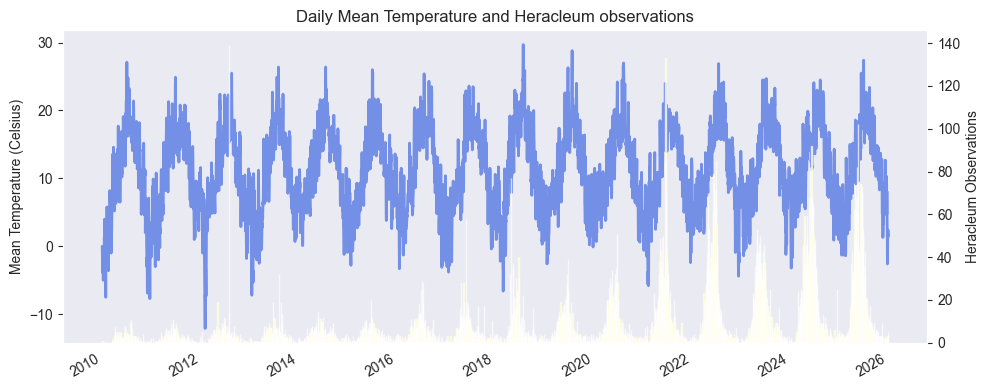

In [66]:
df_daily_counts = df_merged.groupby('eventDate').agg({
    'mean_temp_c': 'mean',
    'Heracleum mantegazzianum': 'sum'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(
    df_daily_counts['eventDate'],
    df_daily_counts['mean_temp_c'],
    color='royalblue',
    linewidth=2,
    alpha=0.7
)

ax1.set_title('Daily Mean Temperature and Heracleum observations')
ax1.set_ylabel('Mean Temperature (Celsius)')
ax1.grid(False)

ax2 = ax1.twinx()
ax2.bar(
    df_daily_counts['eventDate'],
    df_daily_counts['Heracleum mantegazzianum'],
    color='yellow',
    alpha=0.7,
)

ax2.set_ylabel('Heracleum Observations')
ax2.grid(False)

plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

The Heracleum observations peak *significantly* when the mean temperature gets ***higher***, in the spring and summertime, and in the winters, when the temperature *decreases*, the observations also significantly ***decrease***.
(Ruben)

In [67]:
df_merged['cols'] = df_merged['decimalLongitude'].rank(method='dense').astype(np.int16)
df_merged['rows'] = df_merged['decimalLatitude'].rank(method='dense', ascending=False).astype(np.int16)
habitats = pd.read_csv('habitats_cbs_2022_rowscols.csv', engine='pyarrow')

df_merged = df_merged.merge(habitats[['rows', 'cols', 'main_habitat']], on=['rows', 'cols'], how='left')
df_merged = df_merged.rename(columns={'main_habitat': 'habitat_type'})

df_merged['habitat_type'] = df_merged['habitat_type'].astype('category')

df_merged['heracleum_reporting_rate'] = np.where(
    df_merged['total_observations'] > 0,
    df_merged['Heracleum mantegazzianum'] / df_merged['total_observations'],
    0.0
).astype(np.float32)

C:\Users\spec\AppData\Local\Temp\ipykernel_10728\1591265447.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  habitat_subset.drop(rows, inplace=True)


<Axes: xlabel='habitat_type', ylabel='Heracleum mantegazzianum'>

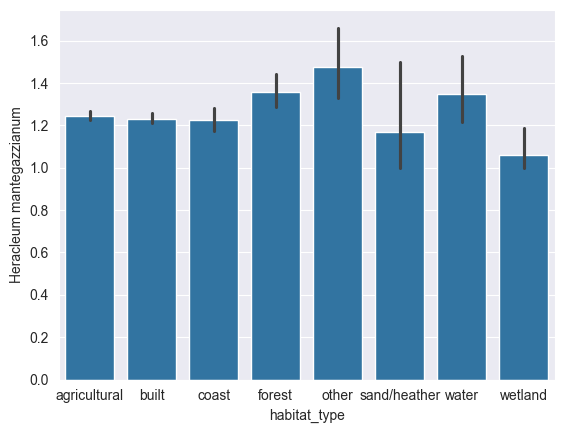

In [68]:
habitat_subset = df_merged[['habitat_type', 'Heracleum mantegazzianum']]

rows = habitat_subset[habitat_subset["Heracleum mantegazzianum"] == 0].index
habitat_subset.drop(rows, inplace=True)

habitat_subset.sample(100)
sns.barplot(habitat_subset, x='habitat_type', y='Heracleum mantegazzianum')

# Modeling


In [69]:
# One-hot encode habitat_types
df_modeling = pd.get_dummies(df_merged, columns=['habitat_type'], drop_first=True)
df_modeling['year'] = pd.to_datetime(df_modeling['eventDate']).dt.year

yearly_grids = []
unique_years = sorted(df_modeling['year'].unique())

# Process data per year to prevent data leakage
for target_year in unique_years:
    df_year = df_modeling[df_modeling['year'] == target_year].copy()
    if df_year.empty:
        continue

    historical_mask = (df_modeling['year'] < target_year) & (df_modeling['Heracleum mantegazzianum'] > 0)

    """
    If more than 5 observations in the dataset, then proceed
    Find 5 closest hotspots -> Average distance to those 5 hotspots + distance to the closest infestation
    If less than 5 big locations, then insert penalty distance of 999 as a placeholder
    """
    if historical_mask.sum() >= 5:
        historical_coords = df_modeling.loc[historical_mask, ['decimalLatitude', 'decimalLongitude']].values
        spatial_tree = cKDTree(historical_coords)
        year_coords = df_year[['decimalLatitude', 'decimalLongitude']].values
        distances, _ = spatial_tree.query(year_coords, k=5)
        df_year['mean_dist_to_top5_clusters'] = np.mean(distances, axis=1)
        df_year['closest_cluster_proximity'] = distances[:, 0]
    else:
        df_year['mean_dist_to_top5_clusters'] = 999.0
        df_year['closest_cluster_proximity'] = 999.0

    """
    If at least 1 plant present, then classification: 1
    Closest group of infestations distance -> Same as below.
    Closest infestation distance -> Passed down as "high-risk" if low enough within a tree of the model
    Mean for weather and such because it averages out for a region, good for our grid-based modeling
    """
    agg_rules = {
        'Heracleum mantegazzianum': 'max',
        'mean_dist_to_top5_clusters': 'mean',
        'closest_cluster_proximity': 'min',
        'mean_temp_c': 'mean',
        'max_temp_c': 'mean',
        'min_temp_c': 'mean',
        'precipitation_mm': 'mean'
    }
    for col in df_year.columns:
        if 'habitat_type_' in col:
            agg_rules[col] = 'max'

    # Explore how serious infestations are within the regions / country
    grid_year = df_year.groupby(['rows', 'cols', 'year']).agg(agg_rules).reset_index()
    grid_year['regional_infestation_pressure'] = historical_mask.sum()
    yearly_grids.append(grid_year)

df_grid_base = pd.concat(yearly_grids, ignore_index=True)

# Builds up the grid, NaN if no records
all_rows = np.arange(df_grid_base['rows'].min(), df_grid_base['rows'].max() + 1)
all_cols = np.arange(df_grid_base['cols'].min(), df_grid_base['cols'].max() + 1)
all_years = df_grid_base['year'].unique()
full_index = pd.MultiIndex.from_product([all_rows, all_cols, all_years], names=['rows', 'cols', 'year'])

df_dense = df_grid_base.set_index(['rows', 'cols', 'year']).reindex(full_index).reset_index()

# For missing weather data, fill in with national average
features_to_smooth = ['mean_temp_c', 'closest_cluster_proximity']
for feat in features_to_smooth:
    df_dense[feat] = df_dense.groupby('year')[feat].transform(lambda x: x.fillna(x.mean()))

# Make the weather / climate data a 3x3 grid for every col/row to smooth out weather calculations
for feat in features_to_smooth:
    smoothed_list = []
    for year in all_years:
        year_df = df_dense[df_dense['year'] == year]
        pivoted_matrix = year_df.pivot(index='rows', columns='cols', values=feat).values
        padded = np.pad(pivoted_matrix, 1, mode='edge')

        smoothed_matrix = np.zeros_like(pivoted_matrix)
        for r in range(1, padded.shape[0] - 1):
            for c in range(1, padded.shape[1] - 1):
                smoothed_matrix[r-1, c-1] = np.mean(padded[r-1:r+2, c-1:c+2])

        df_smoothed_year = pd.DataFrame(smoothed_matrix, index=all_rows, columns=all_cols).stack().reset_index()
        df_smoothed_year.columns = ['rows', 'cols', f'neighborhood_{feat}']
        df_smoothed_year['year'] = year
        smoothed_list.append(df_smoothed_year)

    df_smoothed_feat = pd.concat(smoothed_list, ignore_index=True)
    df_dense = df_dense.merge(df_smoothed_feat, on=['rows', 'cols', 'year'], how='left')

df_dense['presence_filled'] = df_dense['Heracleum mantegazzianum'].fillna(0)

#Roll a 3x3 block over the map to count how many of a cell's 8 touching neighbor squares
# are actively infested. This generates a local exposure risk score from 0 (isolated) to 8 (fully encircled).
presence_smooth_list = []
for year in all_years:
    year_df = df_dense[df_dense['year'] == year]
    pivoted_presence = year_df.pivot(index='rows', columns='cols', values='presence_filled').values
    padded = np.pad(pivoted_presence, 1, mode='constant', constant_values=0)

    neighbor_sum_matrix = np.zeros_like(pivoted_presence)
    for r in range(1, padded.shape[0] - 1):
        for c in range(1, padded.shape[1] - 1):
            neighbor_sum_matrix[r-1, c-1] = np.sum(padded[r-1:r+2, c-1:c+2]) - padded[r, c]

    df_neighbor_sum = pd.DataFrame(neighbor_sum_matrix, index=all_rows, columns=all_cols).stack().reset_index()
    df_neighbor_sum.columns = ['rows', 'cols', 'active_neighbor_infestations']
    df_neighbor_sum['year'] = year
    presence_smooth_list.append(df_neighbor_sum)

df_dense = df_dense.merge(pd.concat(presence_smooth_list, ignore_index=True), on=['rows', 'cols', 'year'], how='left')
df_dense = df_dense.sort_values(by=['rows', 'cols', 'year']).reset_index(drop=True)

# Calculate the speed of the infestations
df_dense['prev_year_proximity'] = df_dense.groupby(['rows', 'cols'])['closest_cluster_proximity'].shift(1)
df_dense['invasion_velocity'] = df_dense['closest_cluster_proximity'] - df_dense['prev_year_proximity']

# If more infestations, then possible outbreak
df_dense['prev_year_neighbor_infestations'] = df_dense.groupby(['rows', 'cols'])['active_neighbor_infestations'].shift(1)
df_dense['neighbor_contagion_momentum'] = df_dense['active_neighbor_infestations'] - df_dense['prev_year_neighbor_infestations']

df_dense['invasion_velocity'] = df_dense['invasion_velocity'].fillna(0)
df_dense['neighbor_contagion_momentum'] = df_dense['neighbor_contagion_momentum'].fillna(0)
df_dense['regional_infestation_pressure'] = df_dense['regional_infestation_pressure'].ffill().bfill()

# Calculates the long-term risk profile of the given cell based on the historical record of the cell
dynamic_priors = []
for target_year in all_years:
    prior_mask = (df_dense['year'] < target_year) & (df_dense['year'] > 2018)
    if prior_mask.sum() > 0:
        prior_map = df_dense[prior_mask].groupby(['rows', 'cols'])['presence_filled'].mean().reset_index()
    else:
        unique_r = df_dense['rows'].unique()
        unique_c = df_dense['cols'].unique()
        full_prod_idx = pd.MultiIndex.from_product([unique_r, unique_c], names=['rows', 'cols'])
        prior_map = pd.DataFrame(index=full_prod_idx).reset_index()
        prior_map['presence_filled'] = 0.0

    prior_map.columns = ['rows', 'cols', 'historical_cell_risk']
    prior_map['year'] = target_year
    dynamic_priors.append(prior_map)

df_priors = pd.concat(dynamic_priors, ignore_index=True)
df_dense = df_dense.merge(df_priors, on=['rows', 'cols', 'year'], how='left')
df_dense['historical_cell_risk'] = df_dense['historical_cell_risk'].fillna(0)

df_grid = df_dense.dropna(subset=['Heracleum mantegazzianum']).reset_index(drop=True)

for col in df_grid.columns:
    if 'habitat_type_' in col:
        df_grid[col] = df_grid[col].fillna(0).astype(np.int8)

feature_cols = [
    'mean_dist_to_top5_clusters', 'closest_cluster_proximity',
    'mean_temp_c', 'max_temp_c', 'min_temp_c', 'precipitation_mm',
    'neighborhood_mean_temp_c', 'neighborhood_closest_cluster_proximity',
    'invasion_velocity', 'neighbor_contagion_momentum', 'regional_infestation_pressure',
    'historical_cell_risk'
] + [col for col in df_grid.columns if 'habitat_type_' in col]

X = df_grid[feature_cols]
y = (df_grid['Heracleum mantegazzianum'] > 0).astype(np.int16)

# Train data covers 2018 up to 2024
train_all_mask = (df_grid['year'] < 2024) & (df_grid['year'] > 2018)
X_train_all, y_train_all = X[train_all_mask], y[train_all_mask]

# ISOLATE 2025 Calendar Year For Target Validation
test_2025_mask = (df_grid['year'] == 2025)
X_test_2025 = X[test_2025_mask]
y_test_2025_cls = y[test_2025_mask]

w_lgb = np.where(y_train_all == 1, 3.5, 1.0)

# Train  LightGBM Classifier
train_data_all_lgb = lgb.Dataset(X_train_all, label=y_train_all, weight=w_lgb)
lgb_params = {
    'objective': 'binary', 'metric': 'average_precision',
    'max_depth': 4, 'num_leaves': 15, 'min_data_in_leaf': 300,
    'learning_rate': 0.03, 'feature_fraction': 0.7, 'verbosity': -1, 'random_state': 42
}
gbm_all = lgb.train(lgb_params, train_data_all_lgb, num_boost_round=400)

# Generate classification probabilities explicitly for 2025
raw_p_lgb_2025 = gbm_all.predict(X_test_2025)

def get_optimal_metrics(y_true, probs):
    precisions, recalls, thresholds = precision_recall_curve(y_true, probs)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    best_idx = np.argmax(f1_scores)
    opt_thresh = thresholds[best_idx]
    preds = (probs >= opt_thresh).astype(np.int16)
    return {
        'Threshold': opt_thresh,
        'Precision': precision_score(y_true, preds, zero_division=0) * 100,
        'Recall': recall_score(y_true, preds, zero_division=0) * 100,
        'F1-Score': f1_score(y_true, preds, zero_division=0) * 100,
        'PR-AUC': average_precision_score(y_true, probs) * 100
    }

results_2025 = {'LightGBM': get_optimal_metrics(y_test_2025_cls, raw_p_lgb_2025)}
df_compare_2025 = pd.DataFrame(results_2025).T
df_compare_2025 = df_compare_2025[['Threshold', 'Precision', 'Recall', 'F1-Score', 'PR-AUC']]

print("=== Stage 1 LightGBM Classification Results (2025) ===")
print(df_compare_2025.round(2).to_string())

# --- STAGE 2 REGRESSION FOR 2025 ---
df_grid['prev_year_infestation'] = df_grid.groupby(['rows', 'cols'])['Heracleum mantegazzianum'].shift(1).fillna(0)
df_grid['infestation_accel'] = df_grid.groupby(['rows', 'cols'])['Heracleum mantegazzianum'].diff().diff().fillna(0)
df_grid['years_occupied'] = df_grid.groupby(['rows', 'cols'])['Heracleum mantegazzianum'].transform(lambda x: (x > 0).cumsum())
df_grid['density_saturation'] = df_grid.groupby(['rows', 'cols'])['Heracleum mantegazzianum'].shift(1) / 10.0

feature_list = feature_cols + ['infestation_accel', 'years_occupied', 'density_saturation']
X_reg = df_grid[feature_list]
y_reg = df_grid['Heracleum mantegazzianum']

X_train_reg = X_reg[train_all_mask]
y_train_reg = y_reg[train_all_mask]

X_test_2025_reg = X_reg[test_2025_mask]
y_test_2025_reg = y_reg[test_2025_mask]

models = {
    "HGBR_Poisson": HistGradientBoostingRegressor(loss='poisson', max_leaf_nodes=64, random_state=63),
    "RandomForest": RandomForestRegressor(n_estimators=150, max_depth=10, n_jobs=-1, random_state=63)
}

test_predictions_2025 = {}
predicted_infected_mask_2025 = (raw_p_lgb_2025 >= 0.60) # 0.60 is the most optimal threshold setting

# Fit individual regressor components on historical true infestations
for name, reg in models.items():
    mask_train = y_train_reg > 0
    X_train_pos = X_train_reg[mask_train]
    y_train_pos_raw = y_train_reg[mask_train].values

    if "Poisson" in name:
        y_train_fit = y_train_reg[mask_train]
    else:
        y_train_fit = y_train_reg[mask_train]

    weights = np.where(y_train_pos_raw > 10, y_train_pos_raw * 1.0, 1.0)
    reg.fit(X_train_pos, y_train_fit, sample_weight=weights)
    y_pred_final_2025 = np.zeros(len(X_test_2025_reg))

    # Gated by the 2025 Standalone LightGBM mask
    if predicted_infected_mask_2025.sum() > 0:
        X_test_targets_2025 = X_test_2025_reg[predicted_infected_mask_2025]

        y_pred_final_2025[predicted_infected_mask_2025] = reg.predict(X_test_targets_2025)

    test_predictions_2025[name] = y_pred_final_2025

# Generate combined prediction vector using Ensemble_RF_Poisson blend
y_pred_ensemble_2025 = (test_predictions_2025["RandomForest"] + test_predictions_2025["HGBR_Poisson"]) / 2

print("\n=== Regression Ensemble Results (2025) ===")
print(f"Ensemble_RF_Poisson R2:  {r2_score(y_test_2025_reg, y_pred_ensemble_2025):.6f}")
print(f"Ensemble_RF_Poisson MAE: {mean_absolute_error(y_test_2025_reg, y_pred_ensemble_2025):.6f}")
print(f"Ensemble_RF_Poisson MSE: {mean_squared_error(y_test_2025_reg, y_pred_ensemble_2025):.6f}")

print("\n=== Actual vs. Predicted Grand Totals ===")
print(f"Total Actual Giant Hogweed Count:    {y_test_2025_reg.sum():.2f}")
print(f"Total Predicted Giant Hogweed Count: {y_pred_ensemble_2025.sum():.2f}")

=== Stage 1 LightGBM Classification Results (2025) ===
          Threshold  Precision  Recall  F1-Score  PR-AUC
LightGBM       0.73      73.13   86.54     79.27   86.41

=== Regression Ensemble Results (2025) ===
Ensemble_RF_Poisson R2:  0.587618
Ensemble_RF_Poisson MAE: 0.493015
Ensemble_RF_Poisson MSE: 1.297276

=== Actual vs. Predicted Grand Totals ===
Total Actual Giant Hogweed Count:    1829.00
Total Predicted Giant Hogweed Count: 2180.06
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34384 entries, 0 to 34383
Data columns (total 31 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   rows                                    34384 non-null  int64  
 1   cols                                    34384 non-null  int64  
 2   year                                    34384 non-null  int32  
 3   Heracleum mantegazzianum                34384 non-null  float64
 4   mean_dist_to_top5_cluste

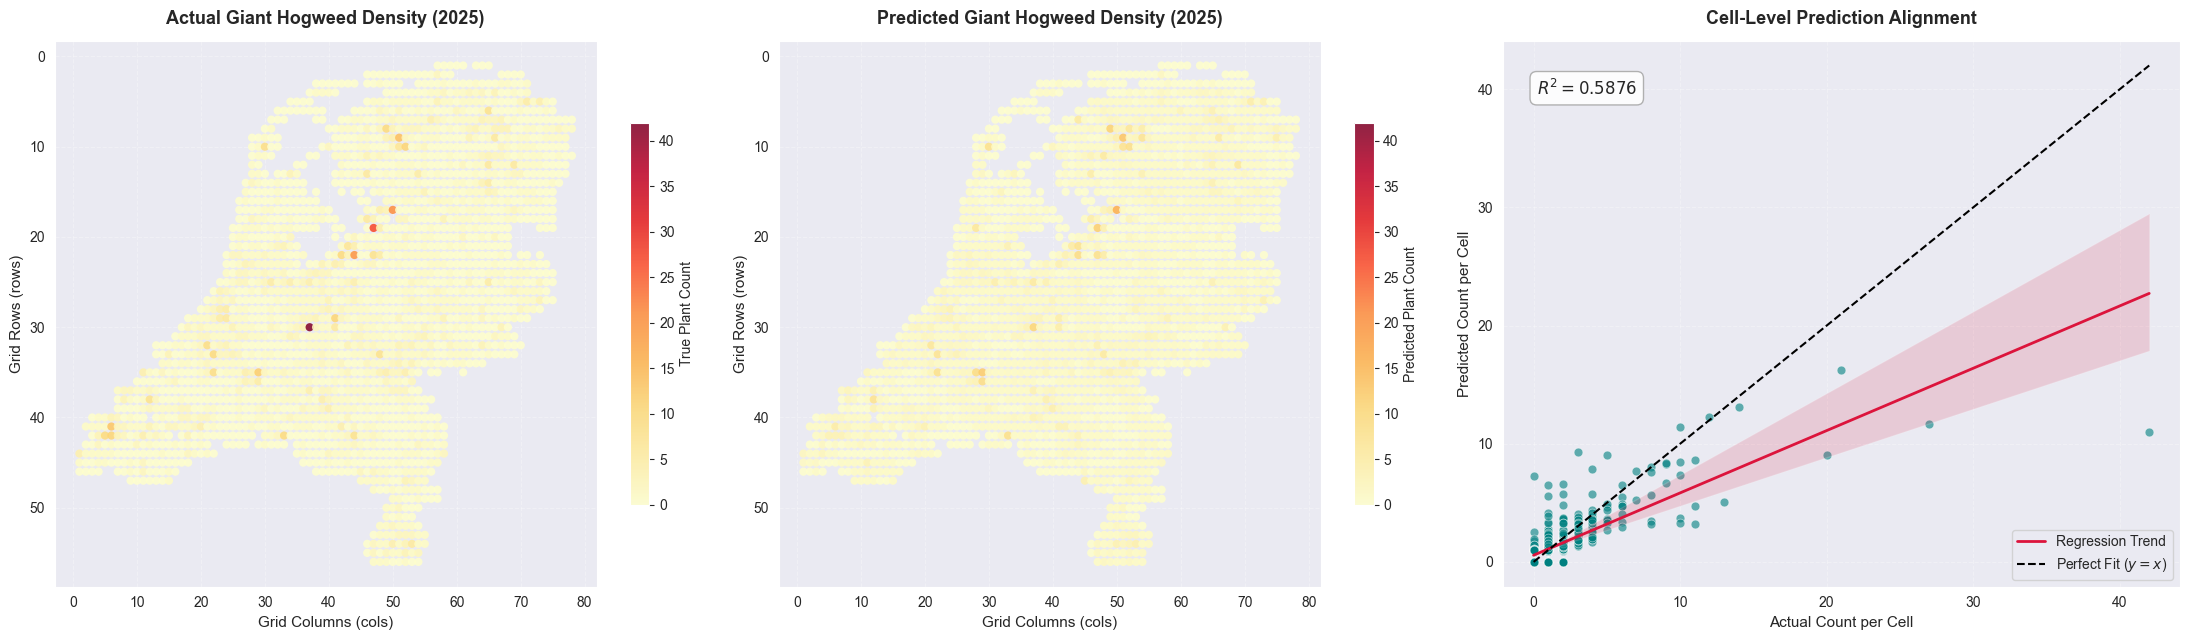

In [70]:
# 1. Isolate the 2025 records and match them with their corresponding actuals and predictions
df_viz_2025 = df_grid[test_2025_mask].copy()
df_viz_2025['Actual_Count'] = y_test_2025_reg.values if hasattr(y_test_2025_reg, 'values') else y_test_2025_reg
df_viz_2025['Predicted_Count'] = y_pred_ensemble_2025

# 2. Initialize a 1-row, 3-column plotting grid
fig, axes = plt.subplots(1, 3, figsize=(22, 6.5))

# Determine the absolute maximum count to standardize the colorbars across maps
max_abundance = df_viz_2025['Actual_Count'].max()

# --- Subplot 1: Spatial Map of Ground Truth (Actual) ---
sc1 = axes[0].scatter(
    df_viz_2025['cols'],
    df_viz_2025['rows'],
    c=df_viz_2025['Actual_Count'],
    cmap='YlOrRd',
    s=35,
    alpha=0.85,
    edgecolors='none',
    vmax=max_abundance
)
axes[0].set_title('Actual Giant Hogweed Density (2025)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Grid Columns (cols)', fontsize=11)
axes[0].set_ylabel('Grid Rows (rows)', fontsize=11)
axes[0].invert_yaxis()  # Invert axis to maintain standard matrix/geographical orientation
axes[0].grid(True, linestyle='--', alpha=0.3)
cbar1 = fig.colorbar(sc1, ax=axes[0], shrink=0.7)
cbar1.set_label('True Plant Count', fontsize=10)

# --- Subplot 2: Spatial Map of Ensemble Predictions ---
sc2 = axes[1].scatter(
    df_viz_2025['cols'],
    df_viz_2025['rows'],
    c=df_viz_2025['Predicted_Count'],
    cmap='YlOrRd',
    s=35,
    alpha=0.85,
    edgecolors='none',
    vmax=max_abundance  # Standardized to show structural shifts or under/over estimation directly
)
axes[1].set_title('Predicted Giant Hogweed Density (2025)', fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Grid Columns (cols)', fontsize=11)
axes[1].set_ylabel('Grid Rows (rows)', fontsize=11)
axes[1].invert_yaxis()
axes[1].grid(True, linestyle='--', alpha=0.3)
cbar2 = fig.colorbar(sc2, ax=axes[1], shrink=0.7)
cbar2.set_label('Predicted Plant Count', fontsize=10)

# --- Subplot 3: Cell-by-Cell Regression & Goodness of Fit ---
sns.regplot(
    data=df_viz_2025,
    x='Actual_Count',
    y='Predicted_Count',
    ax=axes[2],
    color='teal',
    scatter_kws={'alpha': 0.6, 's': 40, 'edgecolor': 'w', 'linewidths': 0.5},
    line_kws={'color': 'crimson', 'lw': 2, 'label': 'Regression Trend'}
)

# Add a dashed y=x identity line to visualize perfect alignment
max_val = max(df_viz_2025['Actual_Count'].max(), df_viz_2025['Predicted_Count'].max())
axes[2].plot([0, max_val], [0, max_val], color='black', linestyle='--', lw=1.5, label='Perfect Fit ($y=x$)')

# Annotate with the exact R2 score calculated for 2025
r2_val = r2_score(df_viz_2025['Actual_Count'], df_viz_2025['Predicted_Count'])
axes[2].text(
    0.05, 0.90, f'$R^2 = {r2_val:.4f}$',
    transform=axes[2].transAxes,
    fontsize=12,
    fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9, edgecolor='darkgray')
)

axes[2].set_title('Cell-Level Prediction Alignment', fontsize=13, fontweight='bold', pad=12)
axes[2].set_xlabel('Actual Count per Cell', fontsize=11)
axes[2].set_ylabel('Predicted Count per Cell', fontsize=11)
axes[2].grid(True, linestyle='--', alpha=0.3)
axes[2].legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

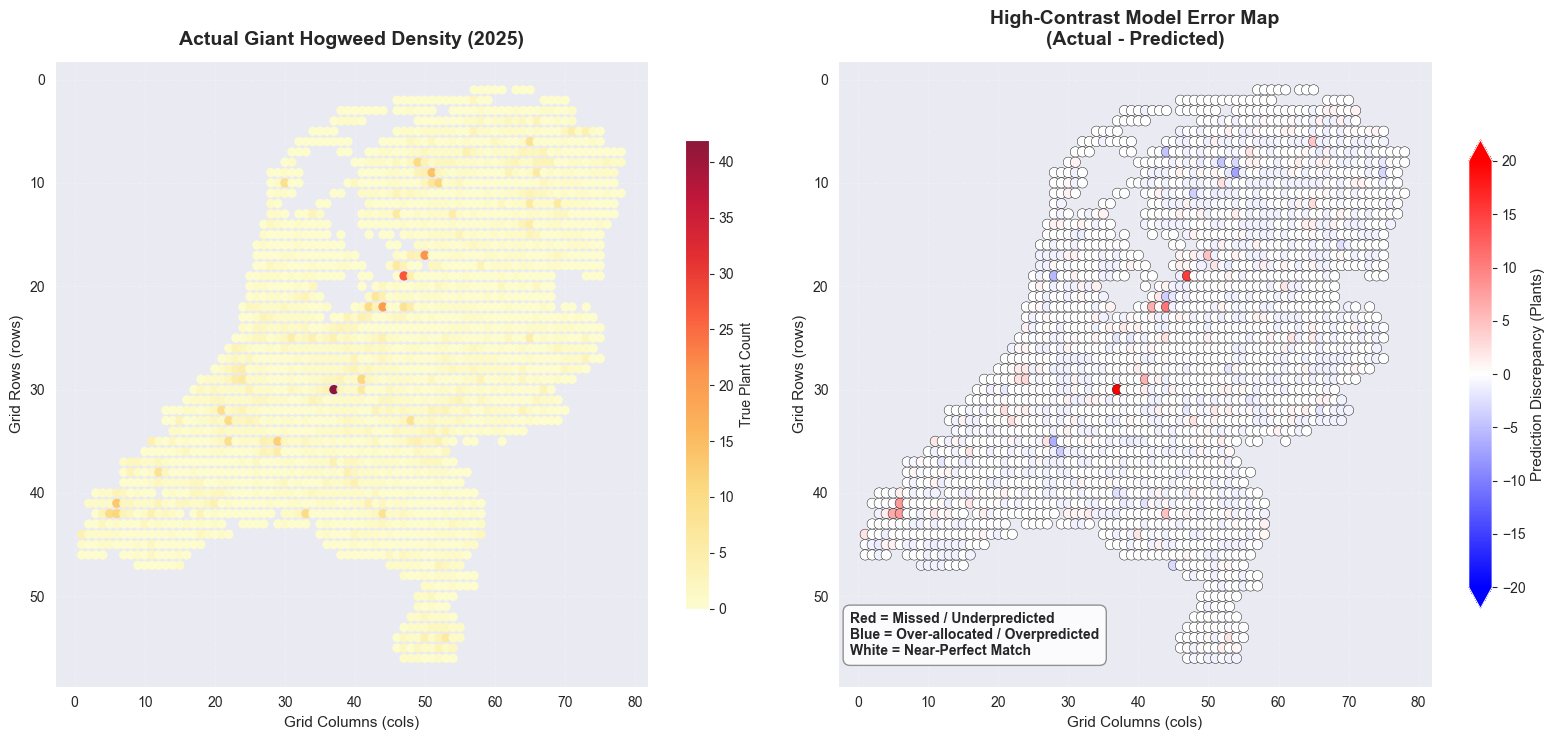

In [71]:
import matplotlib.colors as mcolors
# 1. Prepare data
df_viz_2025 = df_grid[test_2025_mask].copy()
df_viz_2025['Actual_Count'] = y_test_2025_reg.values if hasattr(y_test_2025_reg, 'values') else y_test_2025_reg
df_viz_2025['Predicted_Count'] = y_pred_ensemble_2025

# Calculate exact residual difference
df_viz_2025['Residual'] = df_viz_2025['Actual_Count'] - df_viz_2025['Predicted_Count']

# 2. Build the high-contrast dashboard
fig, axes = plt.subplots(1, 2, figsize=(16, 7.5))

# Panel 1: Baseline Ground Truth Density
max_abundance = df_viz_2025['Actual_Count'].max()
sc1 = axes[0].scatter(
    df_viz_2025['cols'],
    df_viz_2025['rows'],
    c=df_viz_2025['Actual_Count'],
    cmap='YlOrRd',
    s=45,
    alpha=0.9,
    edgecolors='none',
    vmax=max_abundance
)
axes[0].set_title('Actual Giant Hogweed Density (2025)', fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Grid Columns (cols)', fontsize=11)
axes[0].set_ylabel('Grid Rows (rows)', fontsize=11)
axes[0].invert_yaxis()
axes[0].grid(True, linestyle='--', alpha=0.2)
fig.colorbar(sc1, ax=axes[0], shrink=0.75, label='True Plant Count')


# Panel 2: High-Visibility Divergent Error Map
# To make errors in the range of 10s look extremely visible, dynamically restrict vmin/vmax
# to a max boundary of 15-20. This forces anything off by 10+ to saturate completely into deep red or deep blue.
error_bound = min(20, max(abs(df_viz_2025['Residual'].min()), df_viz_2025['Residual'].max()))

sc2 = axes[1].scatter(
    df_viz_2025['cols'],
    df_viz_2025['rows'],
    c=df_viz_2025['Residual'],
    cmap='bwr',                  # Blue (Overpredicted) -> White (Perfect) -> Red (Underpredicted)
    s=55,                        # Slightly larger size to emphasize hot/cold cells
    alpha=1.0,
    edgecolors='black',          # Thin black edge to force isolated errors to pop out
    linewidths=0.3,
    vmin=-error_bound,           # Bounded scale to make mid-range errors look extreme
    vmax=error_bound
)

axes[1].set_title('High-Contrast Model Error Map\n(Actual - Predicted)', fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Grid Columns (cols)', fontsize=11)
axes[1].set_ylabel('Grid Rows (rows)', fontsize=11)
axes[1].invert_yaxis()
axes[1].grid(True, linestyle='--', alpha=0.2)

# Custom colorbar to explain the stark contrast
cbar2 = fig.colorbar(sc2, ax=axes[1], shrink=0.75, extend='both')
cbar2.set_label('Prediction Discrepancy (Plants)', fontsize=11)

# Annotate color map mechanics directly on the plot
axes[1].text(0.02, 0.05, 'Red = Missed / Underpredicted\nBlue = Over-allocated / Overpredicted\nWhite = Near-Perfect Match',
             transform=axes[1].transAxes, fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.85, edgecolor='gray'))

plt.tight_layout()
plt.show()